# Part J: Evaluation Measures and Hypothesis Testing from Scratch

In this notebook, we implement evaluation and validation metrics from scratch using NumPy:
1. **Confusion Matrix, Accuracy, Precision, Recall, and F1-Score**
2. **Receiver Operating Characteristic (ROC) Curve** (TPR vs FPR)
3. **K-Fold Cross Validation**
4. **Bootstrapping**

We evaluate them using a synthetic binary classification dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)

## 1. Confusion Matrix & Classification Metrics from Scratch

We calculate the 4 standard cells of a 2-class confusion matrix:
- **True Positives (TP)**
- **False Positives (FP)**
- **True Negatives (TN)**
- **False Negatives (FN)**

And compute:
- **Accuracy** = (TP + TN) / Total
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1-Score** = 2 * (Precision * Recall) / (Precision + Recall)

In [2]:
def calculate_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, fp, tn, fn

def print_classification_report(y_true, y_pred):
    tp, fp, tn, fn = calculate_confusion_matrix(y_true, y_pred)
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Confusion Matrix:")
    print(f"  [[TN: {tn}, FP: {fp}],")
    print(f"   [FN: {fn}, TP: {tp}]]")
    print(f"\nMetrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

In [3]:
# Generate mock labels
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])
y_pred = np.array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0])

print_classification_report(y_true, y_pred)

Confusion Matrix:
  [[TN: 4, FP: 1],
   [FN: 1, TP: 4]]

Metrics:
  Accuracy:  0.8000
  Precision: 0.8000
  Recall:    0.8000
  F1-Score:  0.8000


## 2. ROC Curve from Scratch

An ROC (Receiver Operating Characteristic) curve plots the True Positive Rate (TPR/Recall) against the False Positive Rate (FPR) for various classification thresholds.

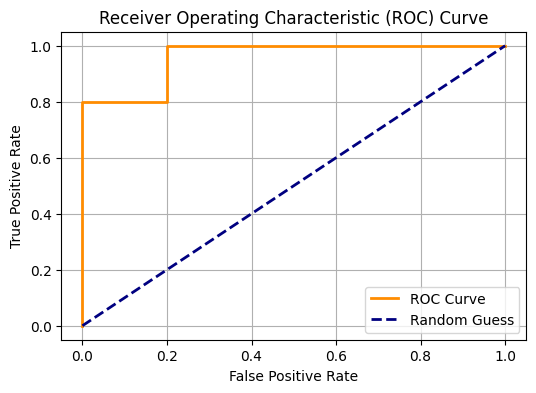

In [4]:
def calculate_roc_curve(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    tprs = []
    fprs = []
    
    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tp, fp, tn, fn = calculate_confusion_matrix(y_true, y_pred)
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        tprs.append(tpr)
        fprs.append(fpr)
        
    return np.array(fprs), np.array(tprs)

# Generate mock probabilities
y_probs = np.array([0.9, 0.1, 0.4, 0.85, 0.6, 0.75, 0.2, 0.3, 0.8, 0.15])
fprs, tprs = calculate_roc_curve(y_true, y_probs)

plt.figure(figsize=(6, 4))
plt.plot(fprs, tprs, color='darkorange', lw=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 3. K-Fold Cross Validation from Scratch

Cross-validation splits the data into $K$ folds, using each fold as a validation set exactly once while training on the remaining $K-1$ folds.

In [5]:
def k_fold_split(n_samples, k=5):
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)
    
    splits = []
    for i in range(k):
        val_indices = folds[i]
        train_indices = np.setdiff1d(indices, val_indices)
        splits.append((train_indices, val_indices))
    return splits

In [6]:
n_samples = 100
splits = k_fold_split(n_samples, k=5)
print(f"Generated {len(splits)}-Fold splits.")
print(f"First fold: Train size = {len(splits[0][0])}, Validation size = {len(splits[0][1])}")

Generated 5-Fold splits.
First fold: Train size = 80, Validation size = 20


## 4. Bootstrapping from Scratch

Bootstrapping generates random datasets by sampling with replacement from the original dataset.

In [7]:
def bootstrap_sample(X, y):
    n_samples = len(y)
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return X[indices], y[indices]

# Create simple dataset
X_mock = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
y_mock = np.array([0, 1, 0, 1])

X_boot, y_boot = bootstrap_sample(X_mock, y_mock)
print("Original Labels:", y_mock)
print("Bootstrap Sampled Labels:", y_boot)

Original Labels: [0 1 0 1]
Bootstrap Sampled Labels: [0 0 1 0]
